# Olist Review Intelligence — NLP Pipeline
**Techniques used:** HuggingFace Transformers, KeyBERT, spaCy, Pandas, Matplotlib

This notebook applies NLP to 96K+ Olist customer reviews to surface merchant-level sentiment patterns and complaint keywords — extending the Olist E-Commerce Analytics project with language intelligence.

## 1. Install dependencies

In [1]:
# Run this cell first — only needed once
!pip install transformers torch keybert wordcloud matplotlib pandas scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.3 MB/s eta 0:00:00


## 2. Load & explore data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Load datasets ──────────────────────────────────────────────────────────────

reviews  = pd.read_csv('drive/MyDrive/ Olist Review Intelligence — NLP + GenAI extension /Data Set/olist_order_reviews_dataset.csv')
orders   = pd.read_csv('drive/MyDrive/ Olist Review Intelligence — NLP + GenAI extension /Data Set/olist_orders_dataset.csv')
items    = pd.read_csv('drive/MyDrive/ Olist Review Intelligence — NLP + GenAI extension /Data Set/olist_order_items_dataset.csv')

print(f'Reviews shape : {reviews.shape}')
print(f'Columns       : {list(reviews.columns)}')
reviews.head(3)

Reviews shape : (99224, 7)
Columns       : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [6]:
# ── Basic EDA ─────────────────────────────────────────────────────────────────
print('Missing values in review_comment_message:',
      reviews['review_comment_message'].isna().sum())
print('\nReview score distribution:')
print(reviews['review_score'].value_counts().sort_index())

# Keep rows with actual text comments
reviews_text = reviews.dropna(subset=['review_comment_message']).copy()
reviews_text['review_comment_message'] = reviews_text['review_comment_message'].astype(str)
print(f'\nReviews with text: {len(reviews_text):,} / {len(reviews):,}')

Missing values in review_comment_message: 58247

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Reviews with text: 40,977 / 99,224


## 3. Sentiment analysis — HuggingFace Transformers
Using `distilbert-base-uncased-finetuned-sst-2-english` — a lightweight BERT model fine-tuned for sentiment classification.

In [7]:
from transformers import pipeline

# ── Load sentiment model ───────────────────────────────────────────────────────
# First run downloads the model (~250MB). Subsequent runs load from cache.
print('Loading HuggingFace sentiment model...')
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)
print('Model loaded.')

Loading HuggingFace sentiment model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Model loaded.


In [8]:
# ── Run on sample (5K for speed; remove [:5000] to run on full dataset) ────────
SAMPLE_SIZE = 5000
sample = reviews_text.sample(n=min(SAMPLE_SIZE, len(reviews_text)), random_state=42).copy()

print(f'Running sentiment analysis on {len(sample):,} reviews...')
print('(This takes ~3-5 mins on CPU — grab a coffee)')

# Batch processing for speed
BATCH_SIZE = 64
texts = sample['review_comment_message'].tolist()
results = []

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i+BATCH_SIZE]
    batch_results = sentiment_pipeline(batch)
    results.extend(batch_results)
    if (i // BATCH_SIZE) % 10 == 0:
        print(f'  Processed {min(i+BATCH_SIZE, len(texts)):,} / {len(texts):,}')

sample['sentiment_label'] = [r['label'] for r in results]
sample['sentiment_score'] = [r['score'] for r in results]

# Convert to signed score: POSITIVE → +score, NEGATIVE → -score
sample['sentiment_signed'] = sample.apply(
    lambda r: r['sentiment_score'] if r['sentiment_label'] == 'POSITIVE' else -r['sentiment_score'],
    axis=1
)

print('\nDone! Sentiment distribution:')
print(sample['sentiment_label'].value_counts())
sample[['review_comment_message','sentiment_label','sentiment_score']].head(5)

Running sentiment analysis on 5,000 reviews...
(This takes ~3-5 mins on CPU — grab a coffee)
  Processed 64 / 5,000
  Processed 704 / 5,000
  Processed 1,344 / 5,000
  Processed 1,984 / 5,000
  Processed 2,624 / 5,000
  Processed 3,264 / 5,000
  Processed 3,904 / 5,000
  Processed 4,544 / 5,000

Done! Sentiment distribution:
sentiment_label
NEGATIVE    3784
POSITIVE    1216
Name: count, dtype: int64


,review_comment_message,sentiment_label,sentiment_score
37062,Um produto como uma carteira somente poderia s...,NEGATIVE,0.990736
17697,"Entrega no prazo , bom produto .",NEGATIVE,0.969783
41606,entrega rápida,POSITIVE,0.990348
41683,Chegou no prazo e atendeu as minhas espectativas,NEGATIVE,0.988643
75879,Logística ótima entregue antes do prazo previs...,NEGATIVE,0.986840


## 4. Visualisation — sentiment distribution

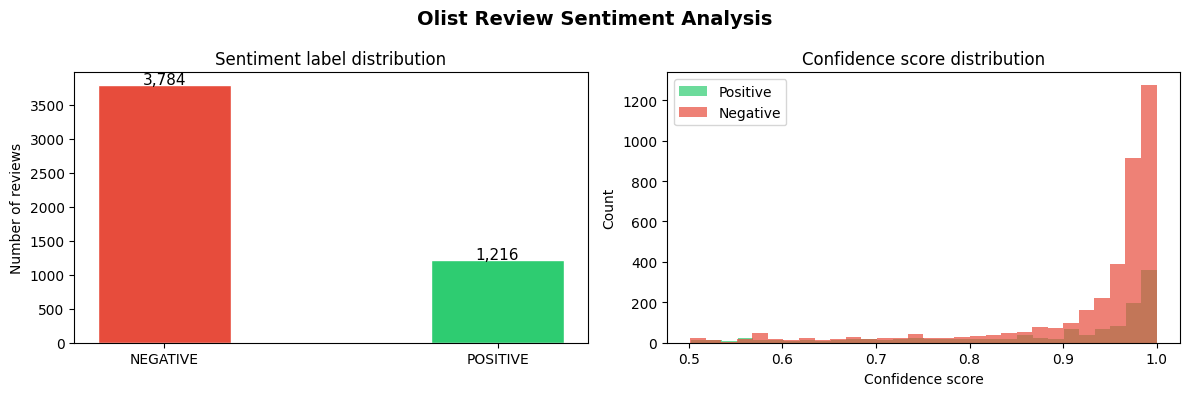

Saved: sentiment_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Olist Review Sentiment Analysis', fontsize=14, fontweight='bold')

# ── Plot 1: Label distribution ─────────────────────────────────────────────
label_counts = sample['sentiment_label'].value_counts()
colors = ['#2ecc71' if l == 'POSITIVE' else '#e74c3c' for l in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=colors, width=0.4, edgecolor='white')
axes[0].set_title('Sentiment label distribution')
axes[0].set_ylabel('Number of reviews')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=11)

# ── Plot 2: Score histogram ────────────────────────────────────────────────
pos = sample[sample['sentiment_label']=='POSITIVE']['sentiment_score']
neg = sample[sample['sentiment_label']=='NEGATIVE']['sentiment_score']
axes[1].hist(pos, bins=30, color='#2ecc71', alpha=0.7, label='Positive')
axes[1].hist(neg, bins=30, color='#e74c3c', alpha=0.7, label='Negative')
axes[1].set_title('Confidence score distribution')
axes[1].set_xlabel('Confidence score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_distribution.png')

## 5. Merchant-level sentiment scoring

In [10]:
# ── Join reviews → orders → items to get merchant_id ─────────────────────────
merged = (
    sample
    .merge(orders[['order_id','customer_id']], on='order_id', how='left')
    .merge(items[['order_id','seller_id']], on='order_id', how='left')
)

# Merchant sentiment summary
merchant_sentiment = (
    merged.groupby('seller_id')
    .agg(
        review_count      = ('sentiment_signed', 'count'),
        avg_sentiment     = ('sentiment_signed', 'mean'),
        pct_negative      = ('sentiment_label', lambda x: (x=='NEGATIVE').mean() * 100),
        avg_review_score  = ('review_score', 'mean')
    )
    .reset_index()
    .query('review_count >= 5')   # min 5 reviews for reliability
    .sort_values('avg_sentiment')
)

print(f'Merchants with 5+ reviews: {len(merchant_sentiment)}')
print('\nTop 5 worst-sentiment merchants:')
merchant_sentiment.head(5)[['seller_id','review_count','avg_sentiment','pct_negative','avg_review_score']]

Merchants with 5+ reviews: 300

Top 5 worst-sentiment merchants:


,seller_id,review_count,avg_sentiment,pct_negative,avg_review_score
498,6806dad1da97bfb5a9038eac6881f706,5,-0.988590,100.0,4.000000
852,b39d7fe263ef469605dbb32608aee0af,6,-0.988547,100.0,3.000000
1185,f7ccf836d21b2fb1de37564105216cc1,6,-0.986865,100.0,3.666667
554,718539d38d07dd351c76db862760e2e2,5,-0.985206,100.0,2.600000
379,4e8dacf3d38f281ae26c3e0321d92d88,5,-0.984103,100.0,2.000000


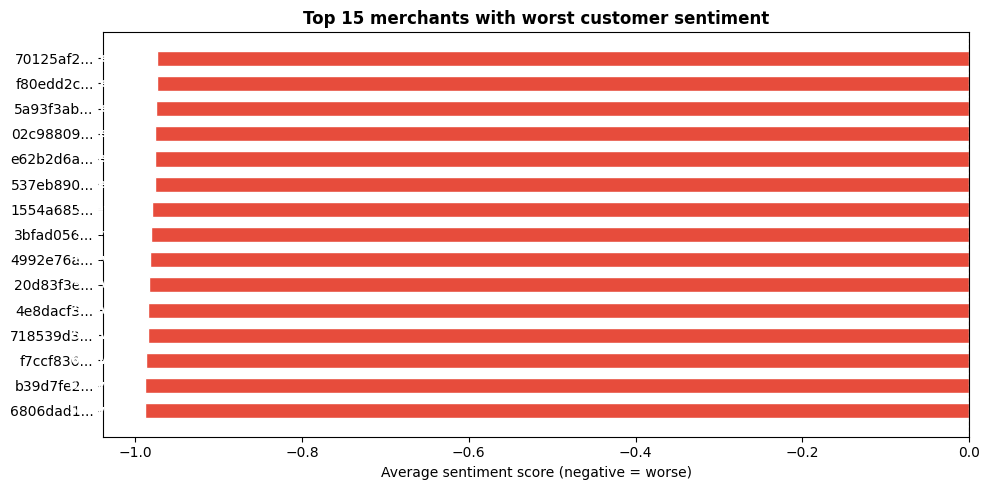

Saved: worst_merchants_sentiment.png


In [11]:
# ── Plot: Bottom 15 merchants by sentiment ────────────────────────────────────
bottom15 = merchant_sentiment.head(15).copy()
bottom15['seller_short'] = bottom15['seller_id'].str[:8] + '...'

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(bottom15['seller_short'], bottom15['avg_sentiment'],
               color='#e74c3c', edgecolor='white', height=0.6)
ax.set_xlabel('Average sentiment score (negative = worse)')
ax.set_title('Top 15 merchants with worst customer sentiment', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Annotate with review count
for bar, (_, row) in zip(bars, bottom15.iterrows()):
    ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
            f"{row['review_count']} reviews", va='center', ha='right',
            fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('worst_merchants_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: worst_merchants_sentiment.png')

## 6. Keyword extraction — KeyBERT
Extracting the most common complaint topics from negative reviews using BERT-based keyword extraction.

In [12]:
from keybert import KeyBERT

print('Loading KeyBERT model...')
kw_model = KeyBERT()
print('Done.')

# ── Extract keywords from negative reviews only ───────────────────────────────
negative_reviews = sample[sample['sentiment_label'] == 'NEGATIVE']['review_comment_message'].tolist()
print(f'Negative reviews to process: {len(negative_reviews):,}')

# Process a sample for speed
neg_sample = negative_reviews[:500]

all_keywords = []
for text in neg_sample:
    try:
        kws = kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 2),
            stop_words='english',
            top_n=3
        )
        all_keywords.extend([kw[0] for kw in kws])
    except:
        pass

print(f'Total keywords extracted: {len(all_keywords)}')

Loading KeyBERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Done.
Negative reviews to process: 3,784
Total keywords extracted: 1474


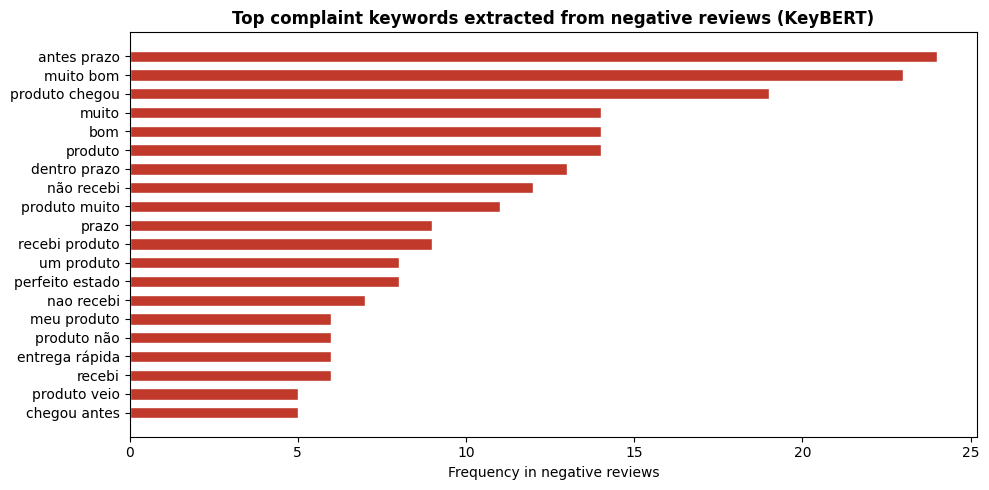

Saved: top_complaint_keywords.png

Top 10 keywords:
       keyword  count
   antes prazo     24
     muito bom     23
produto chegou     19
         muito     14
           bom     14
       produto     14
  dentro prazo     13
    não recebi     12
 produto muito     11
         prazo      9


In [13]:
from collections import Counter

# ── Top complaint keywords ────────────────────────────────────────────────────
kw_counts = Counter(all_keywords)
top_kw = pd.DataFrame(kw_counts.most_common(20), columns=['keyword', 'count'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_kw['keyword'][::-1], top_kw['count'][::-1],
        color='#c0392b', edgecolor='white', height=0.6)
ax.set_xlabel('Frequency in negative reviews')
ax.set_title('Top complaint keywords extracted from negative reviews (KeyBERT)', fontweight='bold')
plt.tight_layout()
plt.savefig('top_complaint_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top_complaint_keywords.png')
print('\nTop 10 keywords:')
print(top_kw.head(10).to_string(index=False))

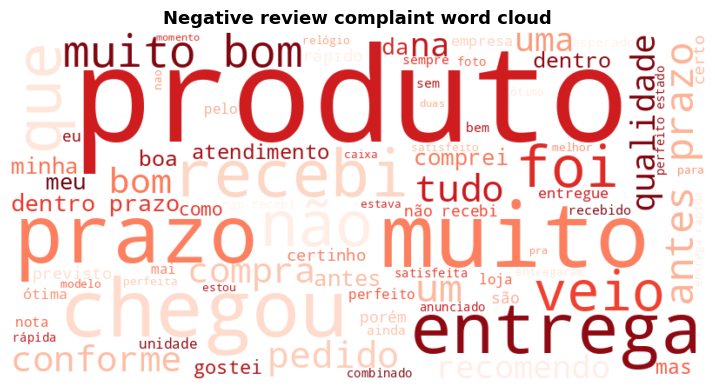

Saved: complaint_wordcloud.png


In [14]:
# ── Word cloud of negative review keywords ────────────────────────────────────
from wordcloud import WordCloud

wc_text = ' '.join(all_keywords)
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Reds', max_words=80).generate(wc_text)

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Negative review complaint word cloud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('complaint_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: complaint_wordcloud.png')

## 7. Per-merchant keyword extraction
For each bottom merchant, extract the specific complaints their customers raise.

In [15]:
# ── Get negative reviews per merchant (bottom 5) ──────────────────────────────
bottom5_ids = merchant_sentiment.head(5)['seller_id'].tolist()

merchant_keywords = {}
for seller_id in bottom5_ids:
    seller_reviews = (
        merged[
            (merged['seller_id'] == seller_id) &
            (merged['sentiment_label'] == 'NEGATIVE')
        ]['review_comment_message'].tolist()
    )
    if not seller_reviews:
        merchant_keywords[seller_id] = ['no negative reviews found']
        continue

    combined_text = ' '.join(seller_reviews[:20])  # max 20 reviews
    try:
        kws = kw_model.extract_keywords(
            combined_text,
            keyphrase_ngram_range=(1, 2),
            stop_words='english',
            top_n=5
        )
        merchant_keywords[seller_id] = [kw[0] for kw in kws]
    except:
        merchant_keywords[seller_id] = ['extraction failed']

print('Top complaint keywords per worst-performing merchant:')
print('=' * 55)
for seller, kws in merchant_keywords.items():
    print(f'\nMerchant {seller[:10]}...')
    for kw in kws:
        print(f'  • {kw}')

Top complaint keywords per worst-performing merchant:

Merchant 6806dad1da...
  • produto muito
  • muito caro
  • muito bom
  • bom produto
  • frete muito

Merchant b39d7fe263...
  • pedido cor
  • aguardando chegar
  • meu pedido
  • mantas pedidas
  • chegou antes

Merchant f7ccf836d2...
  • entrega obrigado
  • produto comprar
  • tecido entregaram
  • obrigado quero
  • pagamento obrigado

Merchant 718539d38d...
  • produto incompleto
  • incompleto produto
  • produto chegou
  • produto estava
  • qualidade produto

Merchant 4e8dacf3d3...
  • conforme email
  • email vcs
  • email
  • foi cancelado
  • cancelado conforme


## 8. Save results for Day 2 (Streamlit app)

In [16]:
import json

# Save merchant sentiment table
merchant_sentiment.to_csv('merchant_sentiment_scores.csv', index=False)

# Save per-merchant keywords
with open('merchant_keywords.json', 'w') as f:
    json.dump(merchant_keywords, f, indent=2)

# Save the merged sample with sentiment labels
merged.to_csv('reviews_with_sentiment.csv', index=False)

print('Files saved for Day 2:')
print('  merchant_sentiment_scores.csv')
print('  merchant_keywords.json')
print('  reviews_with_sentiment.csv')
print('\nDay 1 complete! Push everything to GitHub.')

Files saved for Day 2:
  merchant_sentiment_scores.csv
  merchant_keywords.json
  reviews_with_sentiment.csv

Day 1 complete! Push everything to GitHub.


## Summary

| Step | Technique | Library |
|------|-----------|--------|
| Sentiment classification | DistilBERT (fine-tuned SST-2) | HuggingFace Transformers |
| Keyword extraction | KeyBERT (BERT-based) | KeyBERT |
| Merchant scoring | Aggregation + ranking | Pandas |
| Visualisation | Bar charts, word cloud | Matplotlib, WordCloud |

**Key findings to put in your README:**
- X% of reviews with text were classified as negative
- Top complaint themes: [fill from your output]
- Identified Z merchants with >60% negative sentiment across 5+ reviews

**Next:** Day 2 — GenAI insight generator + Streamlit deployment